In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = {
    'Patient_ID': [201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212],
    'Name': ['Aarav', 'Ishita', 'Rohan', 'Fatima', np.nan, 'Vikram',
             'Ananya', 'Kabir', 'Zara', 'Dev', 'Meera', 'Arjun'],
    'Department': ['Cardiology', 'Orthopedics', 'Cardiology', 'Neurology', 'Orthopedics',
                   'Neurology', 'Cardiology', 'Orthopedics', 'Neurology', 'Cardiology',
                   np.nan, 'Orthopedics'],
    'Age': [45, 62, 38, 29, 71, 55, np.nan, 34, 60, 48, 27, 66],
    'Bill_Amount': [15000, 42000, 8000, np.nan, 30000, 18500,
                     9500, 27000, np.nan, 21000, 6000, 35000],
    'Admit_Date': ['2026-01-03', '2026-01-15', '2026-02-02', '2026-02-10', '2026-02-18',
                    '2026-03-01', '2026-03-05', '2026-03-12', '2026-03-20', '2026-04-02',
                    '2026-04-10', '2026-04-15'],
    'Discharged': [True, True, False, True, True, False, True, True, False, True, True, False]
}
df = pd.DataFrame(data)
df

,Patient_ID,Name,Department,Age,Bill_Amount,Admit_Date,Discharged
0,201,Aarav,Cardiology,45.0,15000.0,2026-01-03,True
1,202,Ishita,Orthopedics,62.0,42000.0,2026-01-15,True
2,203,Rohan,Cardiology,38.0,8000.0,2026-02-02,False
3,204,Fatima,Neurology,29.0,NaN,2026-02-10,True
4,205,NaN,Orthopedics,71.0,30000.0,2026-02-18,True
5,206,Vikram,Neurology,55.0,18500.0,2026-03-01,False
6,207,Ananya,Cardiology,NaN,9500.0,2026-03-05,True
7,208,Kabir,Orthopedics,34.0,27000.0,2026-03-12,True
8,209,Zara,Neurology,60.0,NaN,2026-03-20,False
9,210,Dev,Cardiology,48.0,21000.0,2026-04-02,True


In [3]:
print(df.info())
print("null values : " , df.isnull())
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Patient_ID   12 non-null     int64  
 1   Name         11 non-null     str    
 2   Department   11 non-null     str    
 3   Age          11 non-null     float64
 4   Bill_Amount  10 non-null     float64
 5   Admit_Date   12 non-null     str    
 6   Discharged   12 non-null     bool   
dtypes: bool(1), float64(2), int64(1), str(3)
memory usage: 720.0 bytes
None
null values :      Patient_ID   Name  Department    Age  Bill_Amount  Admit_Date  Discharged
0        False  False       False  False        False       False       False
1        False  False       False  False        False       False       False
2        False  False       False  False        False       False       False
3        False  False       False  False         True       False       False
4        False   True       False  False        F

In [4]:
df['Name']=df['Name'].fillna('Unknown')
df['Department']=df["Department"].fillna(df['Department'].mode() [0])

In [ ]:

df['Department']

0      Cardiology
1     Orthopedics
2      Cardiology
3       Neurology
4     Orthopedics
5       Neurology
6      Cardiology
7     Orthopedics
8       Neurology
9      Cardiology
10     Cardiology
11    Orthopedics
Name: Department, dtype: str

In [9]:
df['Name'] , df['Department']

(0       Aarav
 1      Ishita
 2       Rohan
 3      Fatima
 4     Unknown
 5      Vikram
 6      Ananya
 7       Kabir
 8        Zara
 9         Dev
 10      Meera
 11      Arjun
 Name: Name, dtype: str,
 0      Cardiology
 1     Orthopedics
 2      Cardiology
 3       Neurology
 4     Orthopedics
 5       Neurology
 6      Cardiology
 7     Orthopedics
 8       Neurology
 9      Cardiology
 10     Cardiology
 11    Orthopedics
 Name: Department, dtype: str)

In [10]:
df['Age']=df['Age'].fillna(df['Age'].median())
df['Age']

0     45.0
1     62.0
2     38.0
3     29.0
4     71.0
5     55.0
6     48.0
7     34.0
8     60.0
9     48.0
10    27.0
11    66.0
Name: Age, dtype: float64

In [14]:
df['Bill_Amount']=df["Bill_Amount"].fillna(df.groupby('Department')['Bill_Amount'].transform('mean'))
df['Bill_Amount']

0     15000.0
1     42000.0
2      8000.0
3     18500.0
4     30000.0
5     18500.0
6      9500.0
7     27000.0
8     18500.0
9     21000.0
10     6000.0
11    35000.0
Name: Bill_Amount, dtype: float64

In [16]:
df["Admit_Month"]=df["Admit_Date"].dt.month_name()

AttributeError: Can only use .dt accessor with datetimelike values

In [17]:
df["Admit_Date"].dtype

<StringDtype(storage='python', na_value=nan)>

In [18]:
df["Admit_Date"]=pd.to_datetime(df["Admit_Date"])

In [19]:
df["Admit_Month"]=df["Admit_Date"].dt.month_name()

In [20]:
df["Admit_Date"].dtype

dtype('<M8[us]')

In [21]:
df

,Patient_ID,Name,Department,Age,Bill_Amount,Admit_Date,Discharged,Admit_Month
0,201,Aarav,Cardiology,45.0,15000.0,2026-01-03,True,January
1,202,Ishita,Orthopedics,62.0,42000.0,2026-01-15,True,January
2,203,Rohan,Cardiology,38.0,8000.0,2026-02-02,False,February
3,204,Fatima,Neurology,29.0,18500.0,2026-02-10,True,February
4,205,Unknown,Orthopedics,71.0,30000.0,2026-02-18,True,February
5,206,Vikram,Neurology,55.0,18500.0,2026-03-01,False,March
6,207,Ananya,Cardiology,48.0,9500.0,2026-03-05,True,March
7,208,Kabir,Orthopedics,34.0,27000.0,2026-03-12,True,March
8,209,Zara,Neurology,60.0,18500.0,2026-03-20,False,March
9,210,Dev,Cardiology,48.0,21000.0,2026-04-02,True,April


In [24]:
Still_Admitted=df[df['Discharged']==False].sort_values(by='Bill_Amount' , ascending=False)
print(Still_Admitted)

    Patient_ID    Name   Department   Age  Bill_Amount Admit_Date  Discharged  \
11         212   Arjun  Orthopedics  66.0      35000.0 2026-04-15       False   
5          206  Vikram    Neurology  55.0      18500.0 2026-03-01       False   
8          209    Zara    Neurology  60.0      18500.0 2026-03-20       False   
2          203   Rohan   Cardiology  38.0       8000.0 2026-02-02       False   

   Admit_Month  
11       April  
5        March  
8        March  
2     February  


In [25]:
Avg_bill=df.groupby('Department')['Bill_Amount'].mean()
print(Avg_bill)

Department
Cardiology     11900.0
Neurology      18500.0
Orthopedics    33500.0
Name: Bill_Amount, dtype: float64


In [27]:
High_Revenue=df.groupby('Department')['Bill_Amount'].sum().idxmax()
print(High_Revenue)

Orthopedics


In [30]:
bins=[0,39,60,float("inf")]
lables=['young ' , 'middle_aged' , 'senior']
df['Age_group']=pd.cut(df['Age'] , bins=bins , labels=lables)
print(df[['Age' , 'Age_group']].head(5))

    Age    Age_group
0  45.0  middle_aged
1  62.0       senior
2  38.0       young 
3  29.0       young 
4  71.0       senior


In [32]:
Pivot=df.pivot_table(index='Department' , columns='Discharged' , values='Patient_ID' , aggfunc='count' , margins=True )
print(Pivot)

Discharged   False  True  All
Department                   
Cardiology       1     4    5
Neurology        2     1    3
Orthopedics      1     3    4
All              4     8   12


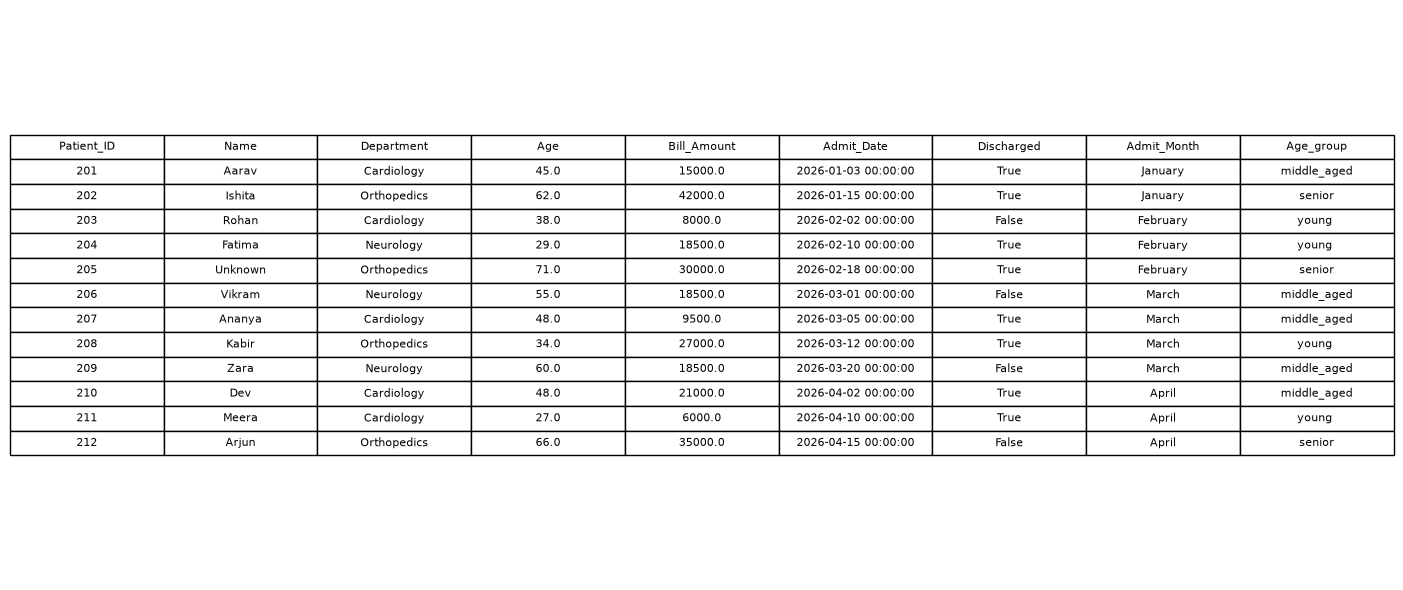

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.2)

plt.tight_layout()
plt.show()

In [ ]:
"""df_styled = (
    df.style
    .set_properties(**{
        "background-color": "#f7f7f7",
        "color": "black",
        "border": "1px solid #d0d0d0",
        "padding": "6px"
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#4C78A8"),
            ("color", "white"),
            ("font-weight", "bold"),
            ("text-align", "center")
        ]},
        {"selector": "tr:nth-of-type(odd)", "props": [("background-color", "#fafafa")]},
        {"selector": "tr:nth-of-type(even)", "props": [("background-color", "#f2f2f2")]}
    ])
)

df_styled
"""


AttributeError: The '.style' accessor requires jinja2

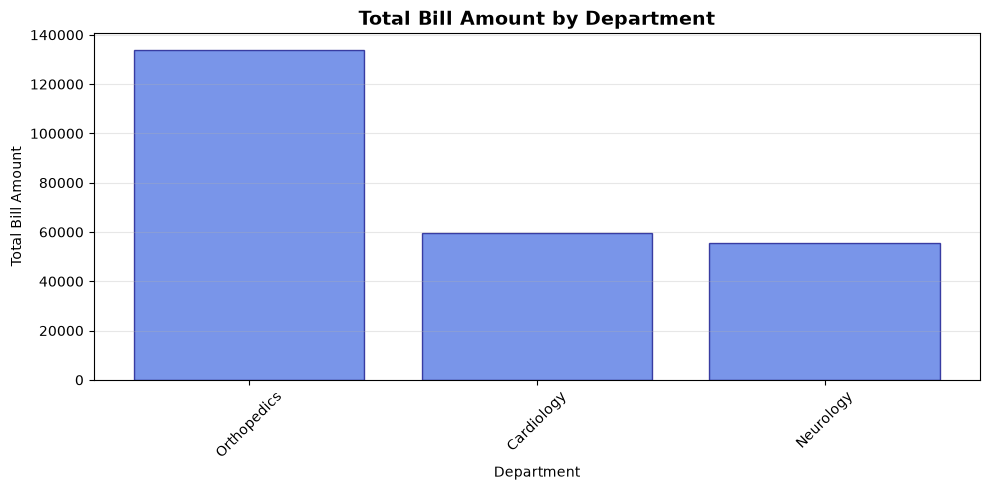

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

dept_bill = df.groupby('Department')['Bill_Amount'].sum().sort_values(ascending=False)

plt.bar(
    dept_bill.index,
    dept_bill.values,
    color='royalblue',
    alpha=0.7,
    edgecolor='navy'
)

plt.title('Total Bill Amount by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Total Bill Amount')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()